In [28]:
# Utils
# ==============================================================================
from keras.utils import to_categorical, set_random_seed

# Data
# ==============================================================================
from keras.datasets import mnist

# Plot
# ==============================================================================
import matplotlib.pyplot as plt

# Data Preprocessing
# ==============================================================================
import pandas as pd
import numpy as np

# Model
# ==============================================================================
from keras.models import Sequential
from keras.layers import (
    Input,
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D
)
from sklearn.model_selection import train_test_split

# Metric
# ==============================================================================
from sklearn.metrics import classification_report, accuracy_score

# **Info**
---

**@By**: Steven Bernal

**@Nickname:** Kaiziferr

**@Git**: https://github.com/Kaiziferr

# **Objective**
---

The objective is to develop a neural network capable of classifying handwritten digit images from the MNIST dataset, correctly identifying the digit represented in each input image.

# **Config**
---

A global random seed is set to 73 using set_random_seed(73), and this value is stored in the random_seed variable.

In [29]:
set_random_seed(73)
random_seed = 73

# **Utils**
---


The optimization_learning_curves() function generates a comparative plot of a metric recorded during both the training and validation phases at each epoch. This visualization makes it possible to analyze the learning or loss curves, helping to assess the model's performance and identify issues such as overfitting or underfitting.


In [30]:
def optimization_learning_curves(
    history:dict,
    metrica:str,
    title:str='',
    X_size:int=8,
    y_size:int=4,
    font_size:int=15,
    X_label:str='Epoch',
    y_label:str='Loss'
)->None:
  """ Grafica curvas de aprendizaje """
  fig, ax = plt.subplots(figsize=(X_size, y_size))
  fig.suptitle(title, fontsize=font_size)
  ax.plot(history.history[metrica])
  ax.plot(history.history[f'val_{metrica}'])
  ax.set_xlabel(X_label, size = 12)
  ax.set_ylabel(y_label, size = 12)
  ax.legend(['Train', 'Test'], loc = 'upper right', fontsize = 12)
  ax.tick_params(labelsize = 12)
  fig.show()

# **Data**
---

The **MNIST** dataset is loaded and automatically split into training and test sets. X_train and X_test contain the digit images, while y_train and y_test contain their corresponding labels.

In [31]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

The input data from the MNIST dataset is reshaped to match the format required by convolutional neural network models. First, the images are reshaped into a four-dimensional format (samples, 28, 28, 1), where the last channel represents grayscale images. Then, the data is converted to float32 to enable efficient numerical operations during model training.

In [32]:
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

The dataset is split into training, validation, test, and hold-out test sets to manage the large amount of available data in a controlled way and ensure a reliable evaluation of the model. The training set is used to learn patterns from the data, while the validation set is used to tune the model and monitor its behavior during training. The test set is used to estimate performance at an intermediate stage of development, and the final hold-out test set is reserved exclusively to measure the model’s generalization ability on completely unseen data.

In [33]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=random_seed)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=random_seed)

# **Preprocesing**
---

This process prepares the data for neural network training by applying two main transformations. First, the images are normalized by dividing the pixel values by 255, rescaling the data to the range [0, 1] and improving the model is numerical stability during training.

In [34]:
X_train = X_train / 255
X_val = X_val / 255
X_test = X_test / 255

Second, the labels are converted to categorical format using to_categorical, transforming integer class labels into one-hot encoded vectors. This allows the model to perform proper multi-class classification, facilitating the computation of the loss function and the interpretation of predictions across each dataset split (training, validation, and test).

In [35]:
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

In [36]:
num_clases = y_test.shape[1]
num_clases

10

# **Model**
---

**Model Architecture**


The architecture_model() function defines a convolutional neural network designed for image classification tasks, specifically adapted to the MNIST dataset. The model is built sequentially, where each layer progressively transforms the data representation:

- It starts with an input layer that defines the image format as 28×28 pixel matrices with a single channel (grayscale).
- Then, a Conv2D convolutional layer with 32 filters of size 5×5 and ReLU activation is used to extract relevant spatial features such as edges and local patterns.
- A MaxPooling2D layer reduces the spatial dimensions of the feature maps, preserving the most important information while decreasing computational complexity.
- A Dropout layer with a rate of 0.2 is applied to help prevent overfitting by randomly deactivating a fraction of neurons during training.
- The output is then flattened using Flatten, converting the 2D representation into a 1D vector for processing by dense layers.
- Next, a fully connected (Dense) layer with 128 neurons, ReLU activation, and He uniform initialization learns non-linear combinations of the extracted features.
- Finally, a 10-neuron output layer with softmax activation produces the probability distribution over the target classes.
- The model is compiled using categorical_crossentropy as the loss function, the Adam optimizer, and accuracy as the evaluation metric, preparing it for supervised multi-class classification training.

In [37]:
def architecture_model():
  model = Sequential()
  model.add(Input(shape=(28,28,1)))
  model.add(Conv2D(32, (5,5), activation='relu'))
  model.add(MaxPooling2D())
  model.add(Dropout(0.2))
  model.add(Flatten())
  model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
  model.add(Dense(10, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

An instance of the previously defined convolutional neural network model is created.

In [38]:
model = architecture_model()

The model training process is initiated using the available data. Validation data is used, allowing the model’s performance to be evaluated on unseen samples during training and its generalization ability to be monitored, as well as helping to detect potential overfitting issues. The training is configured to run for 10 epochs, processing the data in 270 batches of 200 images per iteration.

In [39]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=200,
    verbose=2
)

Epoch 1/10
270/270 - 28s - 104ms/step - accuracy: 0.9218 - loss: 0.2713 - val_accuracy: 0.9760 - val_loss: 0.0835
Epoch 2/10
270/270 - 48s - 179ms/step - accuracy: 0.9767 - loss: 0.0810 - val_accuracy: 0.9820 - val_loss: 0.0507
Epoch 3/10
270/270 - 33s - 124ms/step - accuracy: 0.9831 - loss: 0.0562 - val_accuracy: 0.9873 - val_loss: 0.0399
Epoch 4/10
270/270 - 41s - 152ms/step - accuracy: 0.9864 - loss: 0.0436 - val_accuracy: 0.9883 - val_loss: 0.0366
Epoch 5/10
270/270 - 32s - 118ms/step - accuracy: 0.9891 - loss: 0.0365 - val_accuracy: 0.9903 - val_loss: 0.0345
Epoch 6/10
270/270 - 27s - 99ms/step - accuracy: 0.9907 - loss: 0.0297 - val_accuracy: 0.9890 - val_loss: 0.0342
Epoch 7/10
270/270 - 41s - 151ms/step - accuracy: 0.9921 - loss: 0.0256 - val_accuracy: 0.9893 - val_loss: 0.0354
Epoch 8/10
270/270 - 41s - 153ms/step - accuracy: 0.9937 - loss: 0.0208 - val_accuracy: 0.9897 - val_loss: 0.0374
Epoch 9/10
270/270 - 27s - 99ms/step - accuracy: 0.9944 - loss: 0.0181 - val_accuracy: 0.

In [40]:
X_train.shape[0]/200

270.0

**Determination of the Model's Convergence Point**

The accuracy learning curve shows the evolution of the model’s performance throughout training, comparing the accuracy achieved on the training set versus the validation set.

In the plot, the training accuracy progressively increases from values near 0.92 and stabilizes around 0.99, indicating that the model consistently learns the patterns present in the data.

Validation accuracy also shows a rapid initial increase, reaching values close to 0.99, and then remains stable with minor fluctuations. This behavior suggests that the model has good generalization ability, as there is no significant gap between training and validation performance.

Overall, the shape of both curves indicates a stable learning process, with proper convergence and no clear signs of overfitting.

Convergence, or a point close to it, is reached around epoch 4, where both training and validation accuracy stabilize around 0.99 and show no significant gains in subsequent epochs. This indicates that from that point onward, the model has learned most of the data patterns, and its performance remains consistent.

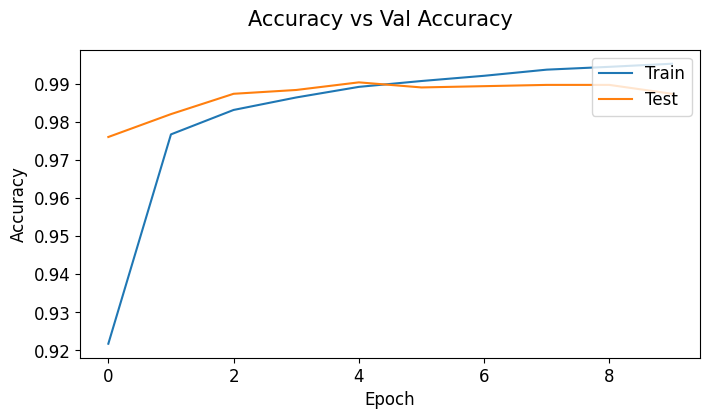

In [41]:
optimization_learning_curves(history, metrica='accuracy', title='Accuracy vs Val Accuracy',y_label ='Accuracy')

**Model Tuning**

In [42]:
model = architecture_model()

The epoch at which convergence occurs is adjusted, and the model is retrained .

In [43]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=200,
    verbose=2
)

Epoch 1/5
270/270 - 28s - 105ms/step - accuracy: 0.9254 - loss: 0.2614 - val_accuracy: 0.9760 - val_loss: 0.0820
Epoch 2/5
270/270 - 41s - 151ms/step - accuracy: 0.9765 - loss: 0.0792 - val_accuracy: 0.9837 - val_loss: 0.0522
Epoch 3/5
270/270 - 40s - 150ms/step - accuracy: 0.9840 - loss: 0.0529 - val_accuracy: 0.9857 - val_loss: 0.0473
Epoch 4/5
270/270 - 41s - 151ms/step - accuracy: 0.9882 - loss: 0.0394 - val_accuracy: 0.9850 - val_loss: 0.0417
Epoch 5/5
270/270 - 27s - 99ms/step - accuracy: 0.9899 - loss: 0.0334 - val_accuracy: 0.9890 - val_loss: 0.0348


In [44]:
score = model.evaluate(X_val, y_val, verbose=0)
print("Performance: %.2f%%" % (score[1]*100))

Performance: 98.90%


Having an accuracy value close to 98.9% indicates that the model performs very well on the digit classification task, as it is able to correctly predict the vast majority of examples in the evaluated dataset. This suggests strong generalization ability, meaning the model not only learns the patterns from the training set but also applies them effectively to unseen data.

In [45]:
print('Accuracy :',score[1])
print('Loss :',score[0])

Accuracy : 0.9890000224113464
Loss : 0.03477345407009125


**Evaluation of the model's performance in prediction**


In [46]:
y_predict_train = model.predict(X_train)
y_predict_val = model.predict(X_val)
y_predict_test = model.predict(X_test)

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


The predictions generated by the model for the training, validation, and test datasets are converted into class labels. For each sample, np.argmax(..., axis=1) returns the index of the maximum value in the corresponding prediction vector, representing the class with the highest predicted probability (or score). The resulting labels are stored in labels_train, labels_val, and labels_test, yielding the predicted class for each sample in the respective dataset.

In [47]:
labels_train = np.argmax(y_predict_train, axis=1)
labels_val = np.argmax(y_predict_val, axis=1)
labels_test = np.argmax(y_predict_test, axis=1)

The model achieved an accuracy of 99.44% on the training set, 98.90% on the validation set, and 98.50% on the test set. These results demonstrate highly consistent performance across the different dataset splits, with variations below 1%. The similarity of the obtained metrics indicates that the model maintains a very high level of accuracy when evaluated on new data, correctly classifying samples in nearly all cases. Overall, the results reflect a robust and effective model for the proposed classification task.

In [48]:
print(f'Data Train: {accuracy_score(y_train, to_categorical(labels_train))}')

Data Train: 0.9943518518518518


In [49]:
print(f'Data Validation: {accuracy_score(y_val, to_categorical(labels_val))}')

Data Validation: 0.989


In [50]:
print(f'Data Test {accuracy_score(y_test, to_categorical(labels_test))}')

Data Test 0.985


# **Info**
---

**@By**: Steven Bernal

**@Nickname:** Kaiziferr

**@Git**: https://github.com/Kaiziferr